# Module 1 — Constant Maturity ("CM")

**Constant maturity of what?** Of *VIX futures prices*.

This notebook is not part of the model. Nothing here changes the model. It reads the
model's own data files so every number you see is real.

## The problem CM solves

The VIX futures listed on the exchange have maturities that change every single day.
A contract that is 35 days from expiry today is 34 days from expiry tomorrow, and in
35 days it is gone and a brand new contract has appeared at the far end.

So if you ask *"how has the 30-day VIX future behaved over the last 22 years?"* there is
**no column of data you can look at.** The data is a conveyor belt, not a time series.

Constant maturity manufactures the missing time series: a price for a VIX future with
*exactly* 30 days left, every day, for 22 years — even though such a contract almost
never actually exists.

**Why you need it:** the whole model is fitted on "when SPX moved, how much did the
30-day point move?" That question cannot be asked without this step.

Run the cells in order. Shift+Enter runs a cell.

In [1]:
import sys, json
from pathlib import Path

import numpy as np
import pandas as pd

REPO = Path.cwd()
while not (REPO / "vixshock").exists() and REPO != REPO.parent:
    REPO = REPO.parent          # walk up until the model package is found
sys.path.insert(0, str(REPO))
pd.set_option("display.width", 200)

print("reading the model's data from:", REPO)

reading the model's data from: C:\Users\vmc30\OneDrive\Desktop\Personal_Repos\Work\VIX


## Step 1 — look at what actually trades on one day

These are the real VIX futures contracts that were listed on the most recent date in
the data. This is the raw material. Note the `days_to_expiry` column: 0, 35, 63, 91,
126, 154... nothing lands on a round number like 30 or 60.

In [2]:
long = pd.read_csv(REPO / "data/processed/vx_long.csv", parse_dates=["date", "contract_expiry"])
asof = long["date"].max()

today = long[long["date"] == asof][
    ["contract_expiry", "days_to_expiry", "settle", "volume", "open_interest"]
].reset_index(drop=True)

print(f"VIX futures listed on {asof.date()}:\n")
print(today.to_string(index=False))
print("\nNotice: no contract has exactly 30, 60, 90 or 120 days to expiry.")
print("Notice also how volume collapses further out - that is why the model stops at 120 days.")

VIX futures listed on 2026-09-18:

contract_expiry  days_to_expiry  settle  volume  open_interest
     2026-10-21              33 18.0411   68215         227566
     2026-11-18              61 18.7049   38965          68644
     2026-12-16              89 19.1250   10044          57685
     2027-01-20             124 19.8901    4242          25138
     2027-02-17             152 20.3000    3715          13345
     2027-03-17             180 20.4750    1446           9053
     2027-04-21             215 20.7750     486           2667
     2027-05-18             242 20.9396      12           1090

Notice: no contract has exactly 30, 60, 90 or 120 days to expiry.
Notice also how volume collapses further out - that is why the model stops at 120 days.


## Step 2 — build the 90-day point by hand

You want a 90-day future. Nothing expires in exactly 90 days. Two contracts straddle it:
one at 63 days, one at 91 days.

90 is almost exactly on top of 91, so you take *almost all* of the 91-day contract and
only a sliver of the 63-day one. The weight is just "how close is each one":

```
distance from 63-day contract to target   = 90 - 63 = 27 days
distance from 91-day contract to target   = 91 - 90 =  1 day
total gap between the two contracts       = 91 - 63 = 28 days

weight on the NEAR (63-day) contract = 1 / 28  = 3.6%
weight on the FAR  (91-day) contract = 27 / 28 = 96.4%
```

The near contract gets a *small* weight because the target is *far* from it. Run the
cell to see this blend reproduce the model's own number exactly.

In [3]:
TARGET = 90  # <-- CHANGE ME to 60 or 120 and re-run to see a different blend

dte = today["days_to_expiry"].to_numpy()
settle = today["settle"].to_numpy()

below = dte[dte <= TARGET].max()
above = dte[dte >= TARGET].min()
px_below = settle[dte == below][0]
px_above = settle[dte == above][0]

gap = above - below
w_near = (above - TARGET) / gap
w_far = 1 - w_near
blended = w_near * px_below + w_far * px_above

print(f"Target maturity: {TARGET} days\n")
print(f"  near contract: {below:>4} days away, price {px_below:.4f}")
print(f"  far  contract: {above:>4} days away, price {px_above:.4f}")
print(f"  gap between them: {gap} days\n")
print(f"  weight on near = ({above} - {TARGET}) / {gap} = {w_near:.4f}  ({w_near*100:.1f}%)")
print(f"  weight on far  = {w_far:.4f}  ({w_far*100:.1f}%)\n")
print(f"  {w_near:.4f} x {px_below:.4f} = {w_near*px_below:.4f}")
print(f"  {w_far:.4f} x {px_above:.4f} = {w_far*px_above:.4f}")
print(f"  {'':>24}  ---------")
print(f"  CM-{TARGET} = {blended:.4f}")

Target maturity: 90 days

  near contract:   89 days away, price 19.1250
  far  contract:  124 days away, price 19.8901
  gap between them: 35 days

  weight on near = (124 - 90) / 35 = 0.9714  (97.1%)
  weight on far  = 0.0286  (2.9%)

  0.9714 x 19.1250 = 18.5786
  0.0286 x 19.8901 = 0.5683
                            ---------
  CM-90 = 19.1469


## Step 3 — check it against what the model computed

The model saved its own working in `data/processed/cm_detail.csv`, including which
contracts it used and the weight it applied. Your hand calculation should match.

In [4]:
detail = pd.read_csv(REPO / "data/processed/cm_detail.csv", parse_dates=["date"])
mine = detail[detail["date"] == asof][
    ["tenor", "level", "w_near", "dte_near", "dte_far", "anchored"]
]

print(f"What the model built on {asof.date()}:\n")
print(mine.to_string(index=False))

model_val = float(mine[mine["tenor"] == TARGET]["level"].iloc[0])
print(f"\nYour hand calc for CM-{TARGET}: {blended:.6f}")
print(f"The model's CM-{TARGET}:        {model_val:.6f}")
print(f"Difference:                 {abs(blended - model_val):.10f}", "  <- match" if abs(blended-model_val) < 1e-6 else "  <- MISMATCH")

What the model built on 2026-09-18:

 tenor     level   w_near  dte_near  dte_far  anchored
    30 17.747364 0.090909         0       33      True
    60 18.681193 0.035714        33       61     False
    90 19.146860 0.971429        89      124     False
   120 19.802660 0.114286        89      124     False
   150 20.270721 0.071429       124      152     False

Your hand calc for CM-90: 19.146860
The model's CM-90:        19.146860
Difference:                 0.0000000000   <- match


## Step 4 — the special case: where spot VIX comes in

Look at the **30-day** row in the table above. Its `dte_near` is **0** — but its
`anchored` flag is **False**. Those two facts sitting together are worth understanding,
because they are easy to confuse (I got this wrong on the first draft of this notebook).

On 2026-09-16 there genuinely *was* a contract with 0 days to expiry — it expired that
morning, settling at 16.79. So the ordinary two-contract blend ran, using that expiring
contract as the near leg. **No spot VIX involved.**

The spot anchor only fires when there is **no contract at or below** the tenor you want.
That is rarer. On those days the model uses **spot VIX as the zero-day point**, and the
justification is worth being able to say out loud:

> *A VIX future settles to spot VIX at expiry. So spot VIX **is** the price of a VIX
> future with zero days to expiry. It is a genuine point on the curve, not a fudge.*

The cell below searches for a date where this actually happened and shows that blend.
This is why the model needs a daily spot VIX feed.

In [5]:
from vixshock.data_sources import load_cboe_index

spot_series = load_cboe_index("vix")
wide = pd.read_csv(REPO / "data/processed/cm_vix.csv", parse_dates=["date"]).set_index("date")

# find the most recent date where the spot anchor actually fired for the 30-day point
anchored = detail[(detail["tenor"] == 30) & (detail["anchored"] == True)].sort_values("date")
ex = anchored.iloc[-1]
ex_date = ex["date"]

# the contracts listed on that date
that_day = long[long["date"] == ex_date][["days_to_expiry", "settle"]].sort_values("days_to_expiry")
spot_then = float(spot_series.loc[ex_date])
front_dte = int(that_day["days_to_expiry"].min())
front_px = float(that_day[that_day["days_to_expiry"] == front_dte]["settle"].iloc[0])

print(f"A genuinely ANCHORED date: {ex_date.date()}\n")
print("contracts listed that day:")
print(that_day.head(4).to_string(index=False))
print(f"\n  -> nearest contract is {front_dte} days out. NOTHING at or below 30 days.")
print(f"  -> so the model reaches for spot VIX as the 0-day point.\n")

w = (front_dte - 30) / front_dte
print(f"spot VIX on {ex_date.date()}: {spot_then:.2f}")
print(f"  weight on spot (0-day point) = ({front_dte} - 30) / {front_dte} = {w:.4f}")
print(f"  {w:.4f} x {spot_then:>7.2f} = {w*spot_then:.4f}   <- spot VIX")
print(f"  {1-w:.4f} x {front_px:>7.4f} = {(1-w)*front_px:.4f}   <- front future")
print(f"  {'':>22}  ---------")
print(f"  CM-30 = {w*spot_then + (1-w)*front_px:.4f}   (model says {ex['level']:.4f})")

n_anch = int(wide["anchored_30"].astype(bool).sum())
print(f"\nThe anchor fired on {n_anch} days out of {len(wide)} ({n_anch/len(wide)*252:.0f} days/year).")
print("Rare - but without it CM-30 would have holes in the history.")

A genuinely ANCHORED date: 2026-09-18

contracts listed that day:
 days_to_expiry  settle
             33 18.0411
             61 18.7049
             89 19.1250
            124 19.8901

  -> nearest contract is 33 days out. NOTHING at or below 30 days.
  -> so the model reaches for spot VIX as the 0-day point.

spot VIX on 2026-09-18: 14.81
  weight on spot (0-day point) = (33 - 30) / 33 = 0.0909
  0.0909 x   14.81 = 1.3464   <- spot VIX
  0.9091 x 18.0411 = 16.4010   <- front future
                          ---------
  CM-30 = 17.7474   (model says 17.7474)

The anchor fired on 276 days out of 5659 (12 days/year).
Rare - but without it CM-30 would have holes in the history.


## Step 5 — what you just built, across 22 years

Doing that blend every day for every tenor gives four continuous time series. *Those*
are what the model is fitted on.

The plot is also the model's **first validation gate**. Three things to look for, because
these are what you would point at if someone challenged the CM construction:

1. **CM-30 tracks spot VIX closely** — correlation 0.965. If the interpolation were
   broken, it wouldn't.
2. **In calm markets the futures sit ABOVE spot** ("term premium") — people pay up for
   crash protection, so the future is priced above where VIX usually lands.
3. **In panics the curve INVERTS** — futures drop below spot, because the market expects
   the panic to subside. Watch 2008 and March 2020.

correlation, CM-30 vs spot VIX : 0.9653
median premium when VIX < 20   : +1.52  <- futures ABOVE spot (calm)
median premium when VIX > 35   : -3.16  <- futures BELOW spot (inverted)
share of VIX>35 days inverted  : 76.7%


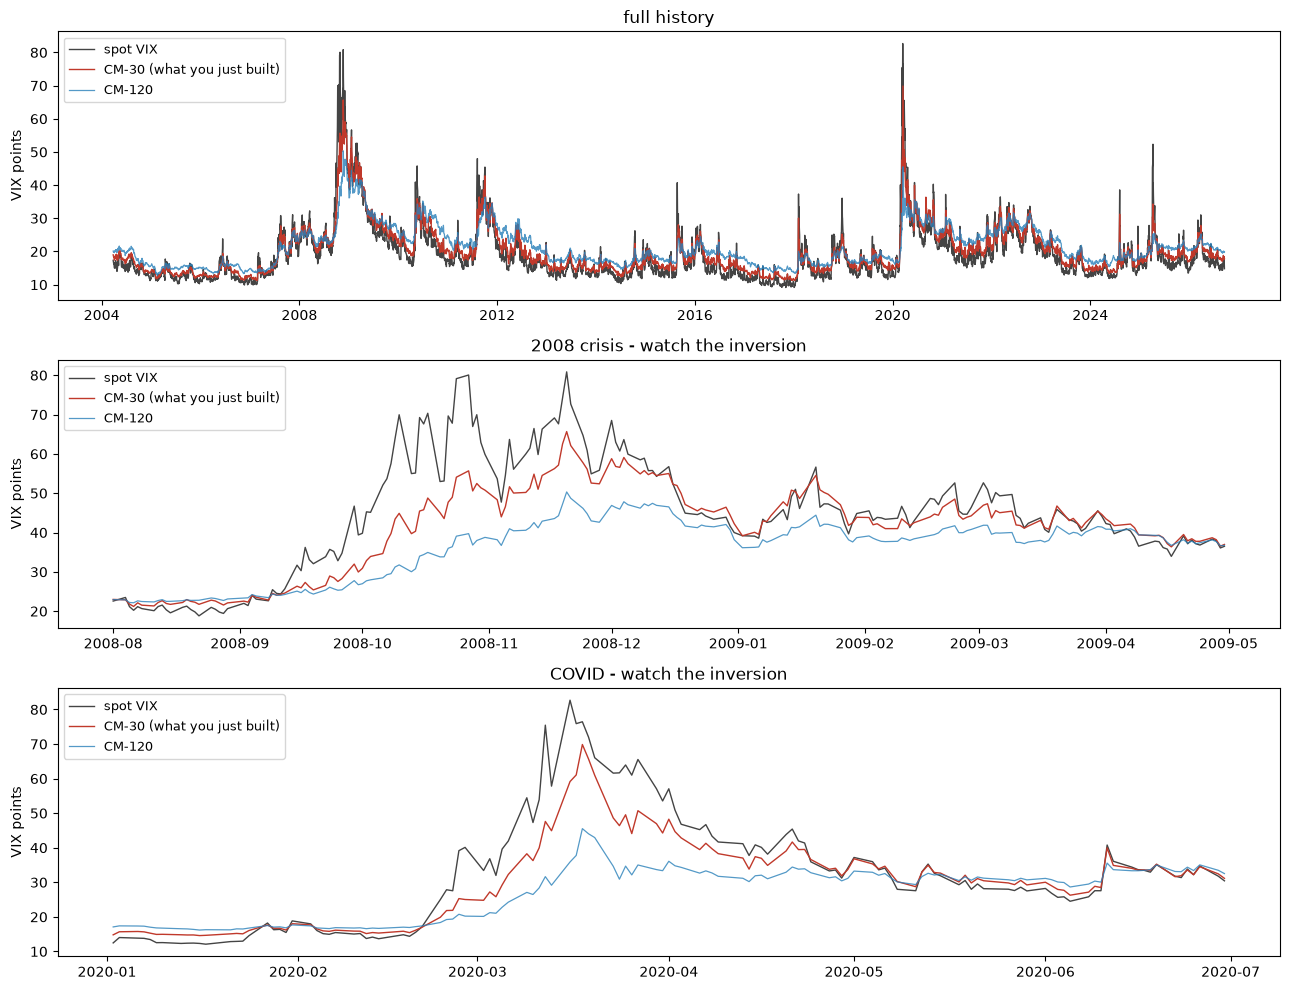

In [6]:
import matplotlib.pyplot as plt

df = pd.DataFrame({"CM-30": wide["cm_30"], "spot VIX": spot_series}).dropna()
prem = df["CM-30"] - df["spot VIX"]
calm, stress = df["spot VIX"] < 20, df["spot VIX"] > 35

print(f"correlation, CM-30 vs spot VIX : {df['CM-30'].corr(df['spot VIX']):.4f}")
print(f"median premium when VIX < 20   : {prem[calm].median():+.2f}  <- futures ABOVE spot (calm)")
print(f"median premium when VIX > 35   : {prem[stress].median():+.2f}  <- futures BELOW spot (inverted)")
print(f"share of VIX>35 days inverted  : {(prem[stress] < 0).mean()*100:.1f}%")

fig, axes = plt.subplots(3, 1, figsize=(13, 10))
for ax, (lo, hi, title) in zip(axes, [("2004", "2027", "full history"),
                                      ("2008-08", "2009-04", "2008 crisis - watch the inversion"),
                                      ("2020-01", "2020-06", "COVID - watch the inversion")]):
    sl = df.loc[lo:hi]
    ax.plot(sl.index, sl["spot VIX"], lw=1.0, label="spot VIX", color="#444")
    ax.plot(sl.index, sl["CM-30"], lw=1.0, label="CM-30 (what you just built)", color="#c0392b")
    ax.plot(sl.index, wide.loc[sl.index, "cm_120"], lw=0.9, label="CM-120", color="#2980b9", alpha=0.8)
    ax.set_title(title)
    ax.legend(loc="upper left", fontsize=9)
    ax.set_ylabel("VIX points")
fig.tight_layout()
plt.show()

Notice in the 2008 and COVID panels: the red line (CM-30) stays **below** the grey line
(spot) during the worst of it, and the blue line (CM-120) is lower still. The far end of
the curve moves much less than the front. That observation is the seed of the whole
response function — it is why the model damps the shock by tenor.

---

## What to take away

**What CM is:** a synthetic daily price for a VIX future of fixed maturity, built by
blending the two real contracts either side of it, weighted by closeness.

**Why it exists:** real contracts roll, so there is no natural 22-year history of "the
30-day future." You have to manufacture one to study history — and the whole model is
fitted on that manufactured history.

**Where spot VIX fits:** as the zero-day point, on the ~12 days a year when no contract
sits at or below the tenor you want. Legitimate because a VIX future settles to spot VIX.
Distinct from the (common) case where an expiring 0-day contract exists and is used
directly.

**The honest weakness, if challenged:** it is *linear* interpolation on a curve that is
not actually straight. Over a ~28-day gap between contracts the error is small, and the
0.965 correlation plus correct inversion behaviour is the evidence it is not material.
Concede the approximation freely, then point at the validation.

**Code:** [`vixshock/cm.py`](../vixshock/cm.py) — the blend is `_interp_one`, about 15
lines. Report section 2 is where the gate is checked.

---

### Questions to test yourself before moving on

1. Why can't you just use the front-month VIX future instead of building CM-30?
2. On a day when the nearest contract is 34 days out, what does the model use for the
   30-day point, and what is the justification?
3. If someone says "linear interpolation is wrong, the curve is convex" — what do you say?
4. Why does the curve invert in a panic, and why is that a sign the construction works?

Next: **Module 2 — Black-76**, which takes these curve levels and turns them into option
prices.